In [23]:
import numpy as np

X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])


In [42]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=100):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []

    #------------------------
    # 1-Training
    #------------------------
    def fit(self, X, y):
        """  
        Fit the model to the data using gradient descent.
        Parameters:
            X : array-like, shape (n_samples,)
                Training data.
            y : array-like, shape (n_samples,)
                Target values.
        """

        n = len(X)

        for _ in range(self.n_iters):
            y_pred = self.theta_1 * X + self.theta_0
            error = y_pred - y

            # gradients
            d_theta_1 = (2/n) * np.sum(error * X)
            d_theta_0 = (2/n) * np.sum(error)

            # update
            self.theta_1 -= self.learning_rate * d_theta_1
            self.theta_0 -= self.learning_rate * d_theta_0

            # calculate SSE
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

    # ------------------------
    # 2-Prediction
    # ------------------------
    def predict(self, X):
        """
        predict target values for given input data.
        Parameters: 
            X : array-like, shape (n_samples,) or (n_samples, 1)
                Input data.
        Returns: array-like, shape (n_samples,)
                Predicted target values.
        """ 
        return self.theta_1 * X + self.theta_0

    # ------------------------
    # 3-MSE
    # ------------------------
    def mse(self, y_true, y_pred):
        """ 
        Calculate Mean Squared Error between true and predicted values.
        Parameters:
            y_true : array-like, shape (n_samples,)
                True target values.
            y_pred : array-like, shape (n_samples,)
                Predicted target values.
        Returns: float
                Mean Squared Error.
        """
        return np.mean((y_true - y_pred) ** 2)

    # ------------------------
    # 4-Visualization
    # ------------------------
    def plot_training(self, X, y):

        # Plot SSE
        plt.figure()
        plt.plot(self.sse_history)
        plt.title("SSE over Iterations")
        plt.xlabel("Iterations")
        plt.ylabel("SSE")
        plt.show()

        # Plot Regression Line
        plt.figure()
        plt.scatter(X, y)
        y_pred = self.predict(X)
        plt.plot(X, y_pred)
        plt.title("Regression Line")
        plt.xlabel("X")
        plt.ylabel("y")
        plt.show()


In [43]:
# Normalize
X = (X - X.mean()) / X.std()
# Train
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)


In [44]:
# Train
model.fit(X, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)


theta_0: 38.100971015430154
theta_1: 7.697558564229364


In [45]:
# Prediction
pred = model.predict(np.array([70]))
print("Predicted price for 70m²:", pred)

Predicted price for 70m²: [576.93007051]


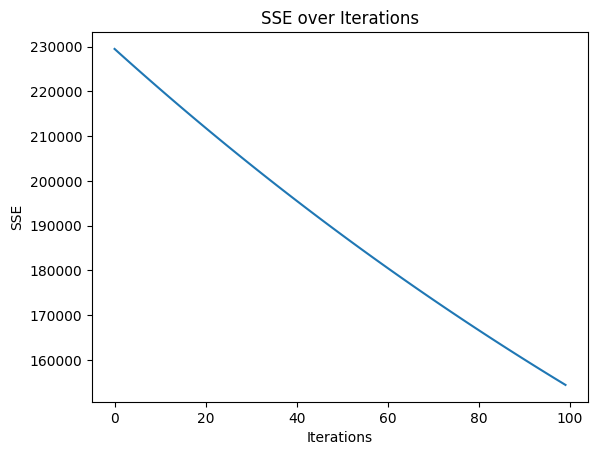

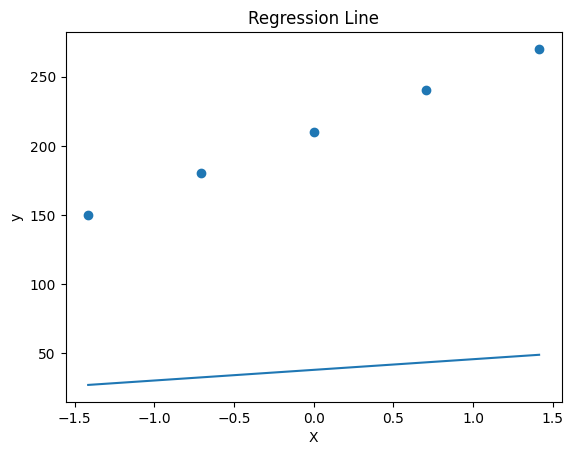

In [46]:
# Visualization
model.plot_training(X, y)